# 03_train_model_A — Train resnet50

Train a pretrained **resnet50** with transfer learning. Crash-resilient:

- Every epoch: training history JSON + epoch CSV → Drive
- Every best val_acc improvement: full training state checkpoint → Drive
- Resume support: if a checkpoint exists, set `RESUME = True` to continue

Output:
- `results/metrics/resnet50_model_card.{md,json}` (committed to GitHub)
- `pk_politicians_results/checkpoints/resnet50_best.pth` (Drive)
- `pk_politicians_results/logs/resnet50_history.json` (Drive)
- `pk_politicians_results/logs/resnet50_epoch_log.csv` (Drive)

## 1. Environment setup

This notebook is designed for **Google Colab (A100)**. The setup cell below:

1. Mounts Google Drive
2. Clones or updates the GitHub repo
3. Installs requirements
4. Adds the repo root to `sys.path` so `from src...` works

In [1]:
import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/musarashid49/Image-Classification-with-CNN.git"
REPO_DIR = Path("/content/Image-Classification-with-CNN")

# 1. Mount Drive
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print("Not in Colab — skipping drive mount.")

# 2. Clone or pull
if REPO_DIR.exists():
    print(f"Repo already cloned at {REPO_DIR}; pulling latest...")
    subprocess.run(["git", "-C", str(REPO_DIR), "pull"], check=False)
else:
    print(f"Cloning {REPO_URL} -> {REPO_DIR}")
    subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)

# 3. Make repo importable
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

# 4. Install requirements (Colab usually has torch already)
req = REPO_DIR / "requirements.txt"
if req.exists():
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(req)], check=False)

os.chdir(REPO_DIR)
print(f"cwd: {os.getcwd()}")
print(f"sys.path[0]: {sys.path[0]}")

Mounted at /content/drive
Cloning https://github.com/musarashid49/Image-Classification-with-CNN.git -> /content/Image-Classification-with-CNN
cwd: /content/Image-Classification-with-CNN
sys.path[0]: /content/Image-Classification-with-CNN


## 2. Config — edit here to switch model or hyperparameters

In [2]:
# ---- Model & training config (single source of truth for this notebook) ----
MODEL_NAME = "resnet50"        # see src/models.py for options
EPOCHS = 35
LR_HEAD = 0.001
LR_BACKBONE = 0.0001
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.05
EARLY_STOPPING_PATIENCE = 8
SCHEDULER_PATIENCE = 3
DROPOUT_HEAD = 0.2
BATCH_SIZE = 32
RESUME = False           # set True to resume from existing checkpoint on Drive
FORCE_RETRAIN = False    # set True to ignore an existing _best checkpoint and retrain

## 3. Imports & setup

In [3]:
import time
import torch
from dataclasses import asdict

from config.config import (
    CLASS_NAMES, DATASET_DIR,
    LOCAL_RESULTS, LOCAL_CHECKPOINTS, LOCAL_METRICS,
    RESULTS_DRIVE, CHECKPOINTS_DRIVE,
    SEED, IMG_SIZE,
)
from src.utils import (
    set_seed, get_device, gpu_info, ensure_dir,
    save_model_card, ExperimentLogger,
)
from src.dataset import build_dataloaders
from src.models import build_model, get_param_groups
from src.train import Trainer, TrainConfig

set_seed(SEED)
device = get_device()
print(f"Device: {device}")
print(f"GPU: {gpu_info() or 'CPU only'}")

Device: cuda
GPU: Tesla T4 (15.6 GB)


## 4. Data loaders

In [ ]:
train_loader, val_loader, test_loader, class_to_idx = build_dataloaders(
    dataset_root=DATASET_DIR,
    batch_size=BATCH_SIZE,
)

print(f"train batches: {len(train_loader)}, "
      f"val batches: {len(val_loader)}, "
      f"test batches: {len(test_loader)}")
print(f"class_to_idx: {class_to_idx}")

train batches: 34, val batches: 7, test batches: 5
class_to_idx: {'ahmed_sharif_chaudhry': 0, 'altaf_hussain': 1, 'asfandyar_wali': 2, 'asif_ali_zardari': 3, 'bilawal_bhutto': 4, 'chaudhry_nisar': 5, 'fazlur_rehman': 6, 'imran_khan': 7, 'maryam_nawaz': 8, 'nawaz_sharif': 9, 'pervez_khattak': 10, 'pervez_musharraf': 11, 'rana_sanaullah': 12, 'shah_mehmood_qureshi': 13, 'shehbaz_sharif': 14, 'sirajul_haq': 15}


## 5. Build model

In [5]:
model, info = build_model(MODEL_NAME, dropout=DROPOUT_HEAD)
param_groups = get_param_groups(
    model,
    lr_head=LR_HEAD, lr_backbone=LR_BACKBONE,
    weight_decay=WEIGHT_DECAY,
)
print(f"Model: {info['model_name']}")
print(f"Total params: {info['total_params']:,} ({info['total_params_M']}M)")
print(f"Trainable: {info['trainable_params']:,}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 171MB/s]


Model: resnet50
Total params: 23,540,816 (23.54M)
Trainable: 23,540,816


## 6. Resume / skip logic

In [6]:
ckpt_path_drive = CHECKPOINTS_DRIVE / f"{MODEL_NAME}_best.pth"
resume_from = None

if ckpt_path_drive.exists():
    print(f"Existing checkpoint found at {ckpt_path_drive}")
    if FORCE_RETRAIN:
        print("FORCE_RETRAIN=True — will retrain from scratch.")
    elif RESUME:
        print("RESUME=True — continuing training from this checkpoint.")
        resume_from = ckpt_path_drive
    else:
        print("Neither RESUME nor FORCE_RETRAIN is True. The trainer will only")
        print("overwrite the checkpoint if a new epoch beats the current val_acc.")
        print("If the existing run is complete, set RESUME=False, run, and watch.")

Existing checkpoint found at /content/drive/MyDrive/pk_politicians_results/checkpoints/resnet50_best.pth
Neither RESUME nor FORCE_RETRAIN is True. The trainer will only
overwrite the checkpoint if a new epoch beats the current val_acc.
If the existing run is complete, set RESUME=False, run, and watch.


## 7. Trainer config + run

In [7]:
cfg = TrainConfig(
    model_name=MODEL_NAME,
    epochs=EPOCHS,
    lr_head=LR_HEAD,
    lr_backbone=LR_BACKBONE,
    weight_decay=WEIGHT_DECAY,
    label_smoothing=LABEL_SMOOTHING,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    scheduler_patience=SCHEDULER_PATIENCE,
)

trainer = Trainer(
    model=model,
    train_loader=train_loader, val_loader=val_loader,
    device=device, cfg=cfg,
    param_groups=param_groups,
    local_results_dir=LOCAL_RESULTS,
    drive_results_dir=RESULTS_DRIVE,
    resume_from=resume_from,
)
run = trainer.run()
print(f"\nTraining complete. best_val_acc={run['best_val_acc']:.4f} "
      f"in {run['duration_seconds']:.1f}s "
      f"({run['epochs_completed']} epochs)")

[trainer] starting resnet50 on cuda


train 1:   0%|          | 0/34 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


val   1:   0%|          | 0/7 [00:00<?, ?it/s]

[epoch 1/35] epoch=1 | train_loss=2.2511 | train_acc=0.3750 | val_loss=1.4839 | val_acc=0.6244 | lr_head=0.0010 | lr_backbone=0.0001 | epoch_seconds=255.3200
  ↑ new best val_acc=0.6244 — saved to Drive: resnet50_best.pth


...

val   28:   0%|          | 0/7 [00:00<?, ?it/s]

[epoch 28/35] epoch=28 | train_loss=0.3253 | train_acc=1.0000 | val_loss=0.5535 | val_acc=0.9220 | lr_head=0.0003 | lr_backbone=0.0000 | epoch_seconds=23.2000
  no improvement (best=0.9220, patience 7/8)


train 29:   0%|          | 0/34 [00:00<?, ?it/s]

val   29:   0%|          | 0/7 [00:00<?, ?it/s]

[epoch 29/35] epoch=29 | train_loss=0.3248 | train_acc=1.0000 | val_loss=0.5443 | val_acc=0.9073 | lr_head=0.0001 | lr_backbone=0.0000 | epoch_seconds=23.4800
  no improvement (best=0.9220, patience 8/8)
[trainer] early stopping at epoch 29
[trainer] done. best_val_acc=0.9220 in 1009.5s

Training complete. best_val_acc=0.9220 in 1009.5s (29 epochs)


## 8. Quick test-set evaluation + model card

In [8]:
from src.evaluate import (
    evaluate_and_save, predict_on_loader, compute_metrics
)
from config.config import LOCAL_PLOTS, REPORT_FIGURES, LOCAL_METRICS

# Load best weights (in case last epoch wasn't best)
from src.train import load_model_for_inference
model = load_model_for_inference(model, trainer.best_path_local, device)

metrics = evaluate_and_save(
    model=model,
    test_loader=test_loader,
    device=device,
    class_names=CLASS_NAMES,
    model_name=MODEL_NAME,
    plots_dir=LOCAL_PLOTS,
    report_dir=REPORT_FIGURES,
    metrics_dir=LOCAL_METRICS,
    history=trainer.history,
)
print(f"\nTest metrics for {MODEL_NAME}:")
print(f"  accuracy:        {metrics['accuracy']:.4f}")
print(f"  macro precision: {metrics['macro_precision']:.4f}")
print(f"  macro recall:    {metrics['macro_recall']:.4f}")
print(f"  macro F1:        {metrics['macro_f1']:.4f}")
print(f"  weighted F1:     {metrics['weighted_f1']:.4f}")


Test metrics for resnet50:
  accuracy:        0.8868
  macro precision: 0.8949
  macro recall:    0.8927
  macro F1:        0.8890
  weighted F1:     0.8854


## 8b. Report figures — normalised confusion matrix + per-class metrics

Saves two PNGs to `REPORT_FIGURES/` with the exact filenames the LaTeX
report expects:

- `{MODEL_NAME}_confusion_matrix_normalized.png`
- `{MODEL_NAME}_per_class_metrics.png`

Drop these into your Overleaf project's `figures/` folder.

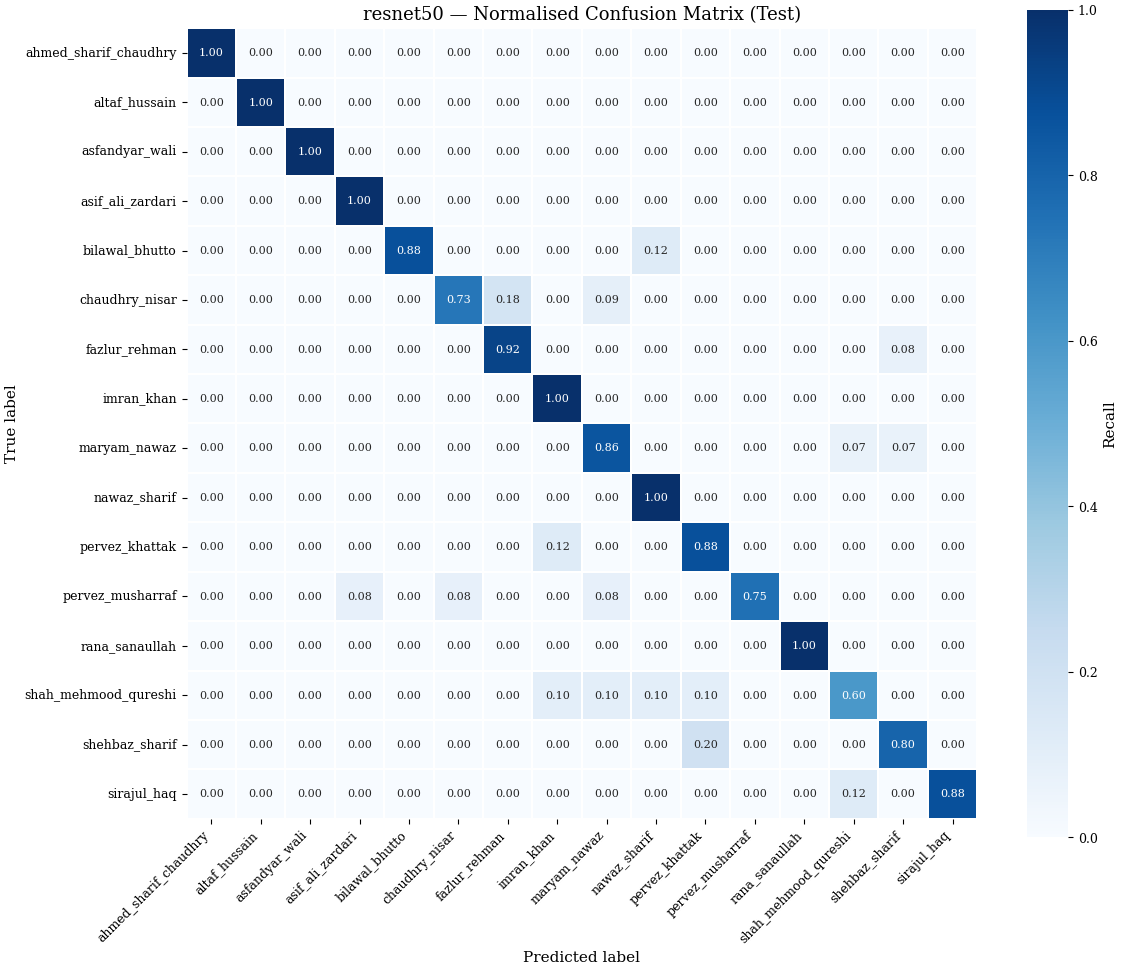

✓ saved: /content/Image-Classification-with-CNN/report/figures/resnet50_confusion_matrix_normalized.png


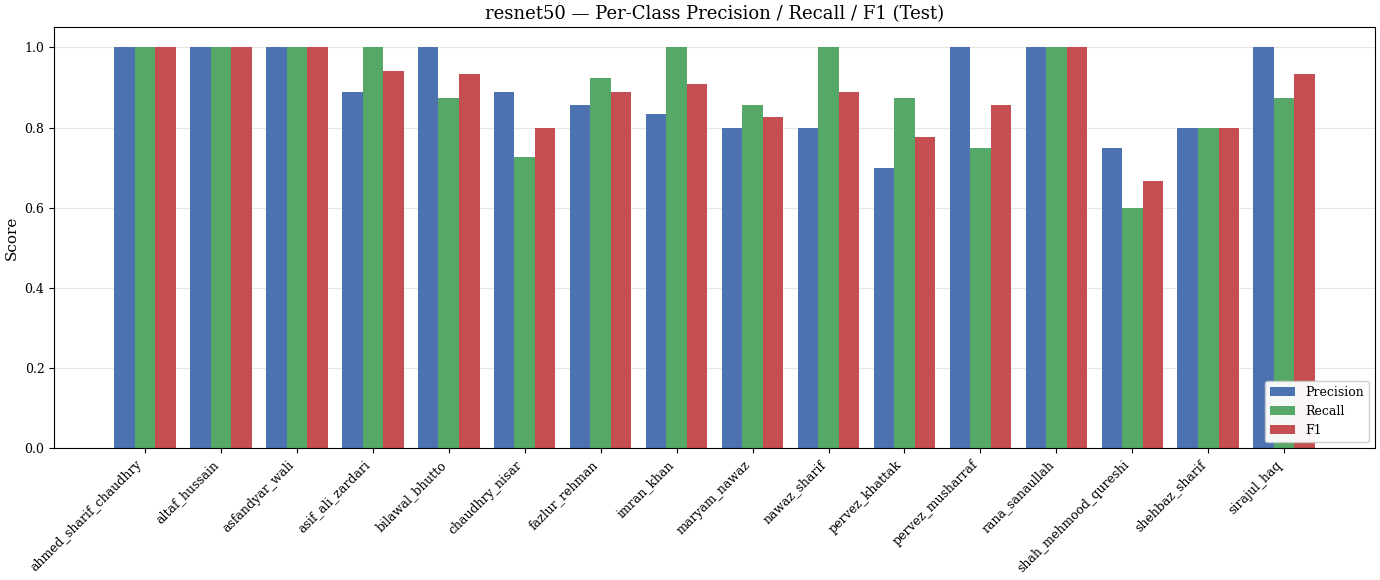

✓ saved: /content/Image-Classification-with-CNN/report/figures/resnet50_per_class_metrics.png

class                          prec    rec     F1    n
ahmed_sharif_chaudhry         1.000  1.000  1.000    8
altaf_hussain                 1.000  1.000  1.000   11
asfandyar_wali                1.000  1.000  1.000   11
asif_ali_zardari              0.889  1.000  0.941    8
bilawal_bhutto                1.000  0.875  0.933    8
chaudhry_nisar                0.889  0.727  0.800   11
fazlur_rehman                 0.857  0.923  0.889   13
imran_khan                    0.833  1.000  0.909   10
maryam_nawaz                  0.800  0.857  0.828   14
nawaz_sharif                  0.800  1.000  0.889    8
pervez_khattak                0.700  0.875  0.778    8
pervez_musharraf              1.000  0.750  0.857   12
rana_sanaullah                1.000  1.000  1.000    9
shah_mehmood_qureshi          0.750  0.600  0.667   10
shehbaz_sharif                0.800  0.800  0.800   10
sirajul_haq              

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

# ---- 1. Collect test-set predictions ----
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = model(images)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.numpy().tolist())

y_true = np.asarray(all_labels)
y_pred = np.asarray(all_preds)
labels_idx = list(range(len(CLASS_NAMES)))

REPORT_FIGURES.mkdir(parents=True, exist_ok=True)

# ---- 2. Normalised confusion matrix (row-normalised = recall) ----
cm = confusion_matrix(y_true, y_pred, labels=labels_idx)
row_sums = cm.sum(axis=1, keepdims=True).clip(min=1)
cm_norm = cm.astype(np.float64) / row_sums

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cbar_kws={"label": "Recall"},
    vmin=0.0, vmax=1.0,
    square=True,
    linewidths=0.3,
    linecolor="white",
    annot_kws={"size": 8},
    ax=ax,
)
ax.set_xlabel("Predicted label", fontsize=11)
ax.set_ylabel("True label", fontsize=11)
ax.set_title(f"{MODEL_NAME} — Normalised Confusion Matrix (Test)", fontsize=13)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

cm_path = REPORT_FIGURES / f"{MODEL_NAME}_confusion_matrix_normalized.png"
fig.savefig(cm_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"✓ saved: {cm_path}")

# ---- 3. Per-class precision / recall / F1 grouped bar chart ----
prec, rec, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=labels_idx, zero_division=0
)

x = np.arange(len(CLASS_NAMES))
w = 0.27

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - w, prec, w, label="Precision", color="#4C72B0")
ax.bar(x,     rec,  w, label="Recall",    color="#55A868")
ax.bar(x + w, f1,   w, label="F1",        color="#C44E52")

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_ylim(0.0, 1.05)
ax.set_ylabel("Score")
ax.set_title(f"{MODEL_NAME} — Per-Class Precision / Recall / F1 (Test)",
             fontsize=13)
ax.legend(loc="lower right", framealpha=0.95)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()

pc_path = REPORT_FIGURES / f"{MODEL_NAME}_per_class_metrics.png"
fig.savefig(pc_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"✓ saved: {pc_path}")

# ---- 4. Quick numeric summary printed under the bars ----
print()
print(f"{'class':28s} {'prec':>6s} {'rec':>6s} {'F1':>6s} {'n':>4s}")
for name, p, r, f, s in zip(CLASS_NAMES, prec, rec, f1, support):
    print(f"{name:28s} {p:6.3f} {r:6.3f} {f:6.3f} {int(s):4d}")


In [ ]:
from config.config import RESULTS_DRIVE

METRICS_DRIVE = RESULTS_DRIVE / "metrics"
METRICS_DRIVE.mkdir(parents=True, exist_ok=True)

card_paths = save_model_card(
    model_name=MODEL_NAME,
    model_info=info,
    training_config=asdict(cfg),
    final_metrics={
        "test_accuracy":          metrics["accuracy"],
        "test_macro_precision":   metrics["macro_precision"],
        "test_macro_recall":      metrics["macro_recall"],
        "test_macro_f1":          metrics["macro_f1"],
        "test_weighted_f1":       metrics["weighted_f1"],
        "best_val_acc":           run["best_val_acc"],
        "epochs_completed":       run["epochs_completed"],
    },
    training_duration_seconds=run["duration_seconds"],
    checkpoint_drive_path=str(trainer.best_path_drive),
    output_dir=METRICS_DRIVE,                   # ← Drive, not repo
    notebook_name="03_train_model_A.ipynb",
    notes="Trained on dataset_resplit (75/15/10 split, per-class).",
)
print(f"✓ model card (md):   {card_paths['md']}")
print(f"✓ model card (json): {card_paths['json']}")

# Experiment log — also on Drive
ExperimentLogger(METRICS_DRIVE / "experiment_log.jsonl").log({
    "model":            MODEL_NAME,
    "test_accuracy":    metrics["accuracy"],
    "macro_f1":         metrics["macro_f1"],
    "epochs":           run["epochs_completed"],
    "duration_seconds": run["duration_seconds"],
})
print(f"✓ experiment log appended: {METRICS_DRIVE / 'experiment_log.jsonl'}")

print()
print("When ready to commit these to GitHub, copy them into results/metrics/ and push:")
print(f"  cp {METRICS_DRIVE}/*.json  /content/Image-Classification-with-CNN/results/metrics/")
print(f"  cp {METRICS_DRIVE}/*.md    /content/Image-Classification-with-CNN/results/metrics/")

✓ model card (md):   /content/drive/MyDrive/pk_politicians_results/metrics/resnet50_model_card.md
✓ model card (json): /content/drive/MyDrive/pk_politicians_results/metrics/resnet50_model_card.json
✓ experiment log appended: /content/drive/MyDrive/pk_politicians_results/metrics/experiment_log.jsonl

When ready to commit these to GitHub, copy them into results/metrics/ and push:
  cp /content/drive/MyDrive/pk_politicians_results/metrics/*.json  /content/Image-Classification-with-CNN/results/metrics/
  cp /content/drive/MyDrive/pk_politicians_results/metrics/*.md    /content/Image-Classification-with-CNN/results/metrics/
